### 1b. Preprocessing and Exploratory Data Analysis

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns
import math
%matplotlib inline
pd.options.display.max_columns = 100

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import learning_curve
from sklearn.neighbors import DistanceMetric

In [2]:
dat_files = glob.glob("./vertebral_column_data/*.dat")
arff_files = glob.glob("./vertebral_column_data/*.arff")
dat_files, arff_files

(['./vertebral_column_data/column_2C.dat',
  './vertebral_column_data/column_3C.dat'],
 ['./vertebral_column_data/column_3C_weka.arff',
  './vertebral_column_data/column_2C_weka.arff'])

In [3]:
# Our file of concern is column_2C.dat 
# Our classification tasks involves only two classes - normal and abnormal
lines = []
with open(dat_files[0]) as f:
    line = f.readline()
    lines.append(line.strip("\n"))
    #print(line)
    while line:
        line = f.readline()
        #print(line)
        lines.append(line.strip("\n"))
lines = lines[:-1]
print("Number of records :- ",len(lines))

Number of records :-  310


In [4]:
# convert list of records into a dataframe
cols = ['pelvic_incidence','pelvic_tilt','lumbar_lordosis_angle', \
        'sacral_slope','pelvic_radius','degree_spondylolisthesis','result']

vertebral = pd.DataFrame()
for l in lines:
    ser = pd.Series(l.split(" "))
    vertebral = vertebral.append(ser,ignore_index=True)
vertebral.columns = cols
print("Shape of Dataframe :- ",vertebral.shape)

Shape of Dataframe :-  (310, 7)


In [5]:
vertebral.head()

,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,result
0,63.03,22.55,39.61,40.48,98.67,-0.25,AB
1,39.06,10.06,25.02,29,114.41,4.56,AB
2,68.83,22.22,50.09,46.61,105.99,-3.53,AB
3,69.3,24.65,44.31,44.64,101.87,11.21,AB
4,49.71,9.65,28.32,40.06,108.17,7.92,AB


In [6]:
# convert string values to numeric
vertebral[['pelvic_incidence','pelvic_tilt','lumbar_lordosis_angle', \
        'sacral_slope','pelvic_radius','degree_spondylolisthesis']] = \
vertebral[['pelvic_incidence','pelvic_tilt','lumbar_lordosis_angle', \
        'sacral_slope','pelvic_radius','degree_spondylolisthesis']].apply(pd.to_numeric)

# AB = 1, NO = 0
vertebral.loc[vertebral['result'] == 'AB', 'result'] = 1
vertebral.loc[vertebral['result'] == 'NO', 'result'] = 0

In [7]:
vertebral.dtypes

pelvic_incidence            float64
pelvic_tilt                 float64
lumbar_lordosis_angle       float64
sacral_slope                float64
pelvic_radius               float64
degree_spondylolisthesis    float64
result                        int64
dtype: object

In [8]:
# Count of null values
vertebral.isnull().sum()

pelvic_incidence            0
pelvic_tilt                 0
lumbar_lordosis_angle       0
sacral_slope                0
pelvic_radius               0
degree_spondylolisthesis    0
result                      0
dtype: int64

#### 1b(i)  Make scatterplots of the independent variables in the dataset.  Use color to show Classes 0 and 1.

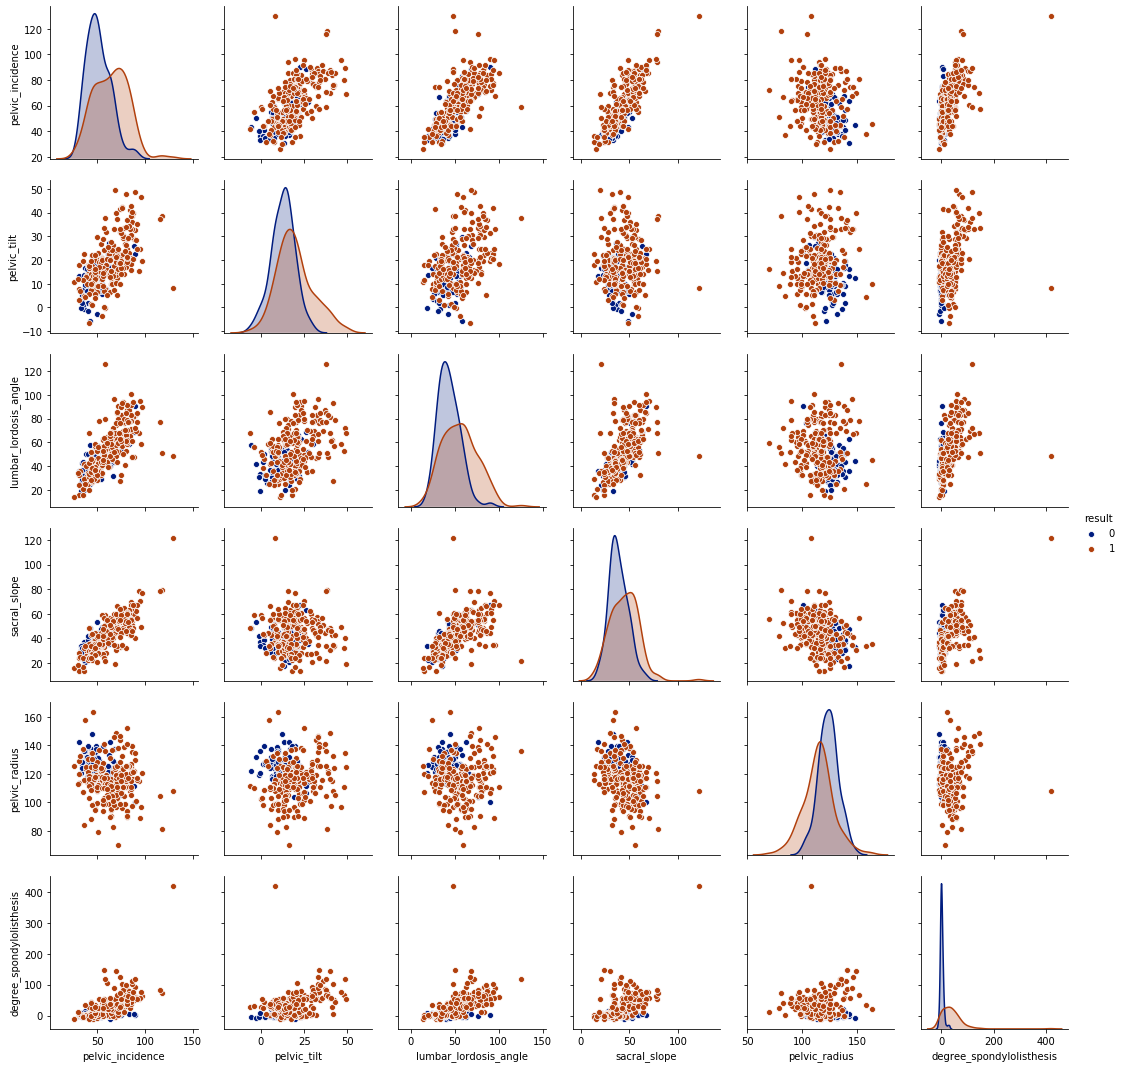

In [9]:
features = ['pelvic_incidence','pelvic_tilt','lumbar_lordosis_angle', \
        'sacral_slope','pelvic_radius','degree_spondylolisthesis']

sns.pairplot(vertebral, vars = vertebral.columns[:-1], hue = "result", palette = "dark", dropna = True)

#### Columns with positive correlation - (pelvic tilt, pelvic_incidence),(lumbar_lordosis_angle, pelvic_incidence), (degree_spondylolisthesis, pelvic_incidence), (pelvic_radius, degree_spondylolisthesis),(lumbar_lurdosis_angle,sacral_scope)

#### 1b(ii) Make  boxplots  for  each  of  the  independent  variables.   Use  color  to  show Classes 0 and 1.

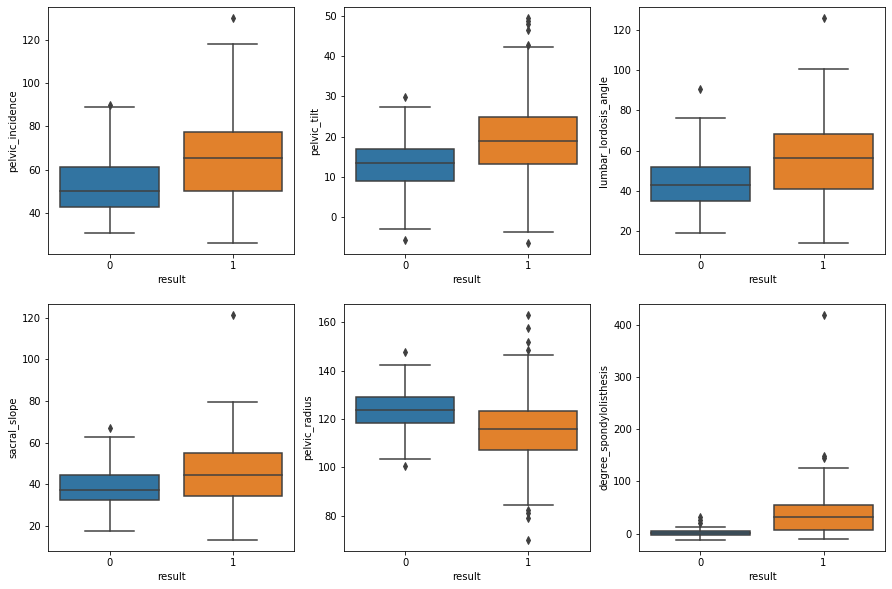

In [10]:
row = 2
col = 3
plot = 1
plt.figure(figsize = (15,10))
for f in features:
    plt.subplot(row,col,plot)
    ax = sns.boxplot(y = f, x = 'result', data = vertebral)
    plot += 1


#### 1b(iii) Select  the  first  70  rows of  Class  0  and  the  first  140  rows  of  Class  1  as the training set and the rest of the data as the test set.

In [11]:
training = pd.concat([vertebral[vertebral.result == 0][0:70],vertebral[vertebral.result == 1][0:140]])
testing = pd.concat([vertebral[vertebral.result == 0][70:],vertebral[vertebral.result == 1][140:]])
# Verify shape
print("Dataset :- ",vertebral.shape, "\nTraining :-",training.shape, "\nTesting :- ",testing.shape)

Dataset :-  (310, 7) 
Training :- (210, 7) 
Testing :-  (100, 7)


### 1c. Classification using KNN on Vertebral Column Data Set

#### 1c(i) Write code for k-nearest neighbors with Euclidean metric (or use a softwarepackage).

In [12]:
# Split the data into train and test with a ratio of 80:20
X = training.iloc[:,0:6]
y = training.iloc[:,6]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 4)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

# Build the classifier
# default value of k is 5
# metric for distance - Euclidean
model = KNeighborsClassifier(n_neighbors = 5, p = 2, metric = 'euclidean')
# compile the model
model.fit(X_train,y_train)
# predict for test 
y_pred = model.predict(X_test)
scores = metrics.accuracy_score(y_test, y_pred)
print(scores)
another_test_features = testing.iloc[:,0:6]
another_test_target = testing.iloc[:,6]
another_ypred = model.predict(another_test_features)
another_scores = metrics.accuracy_score(another_test_target,another_ypred)
print(another_scores)

(168, 6) (42, 6) (168,) (42,)
0.7619047619047619
0.91


#### 1c(ii)  Test  all  the  data  in  the  test  database  with k nearest  neighbors. Take  decisions  by  majority  polling.  Plot  train  and  test  errors  in  terms  of k for k∈{208,205, . . . ,7,4,1,} (in reverse order).  You are welcome to use smaller increments of k.  Which k∗ is the most suitable k among those values?  Calculate the confusion matrix, true positive rate, true negative rate, precision,and F-score when k = k∗.

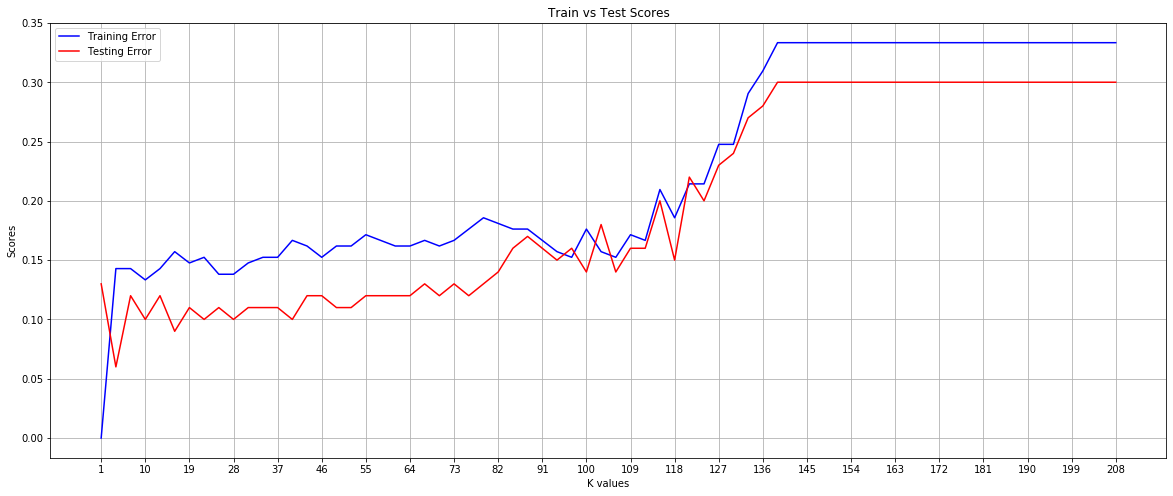

In [13]:
X_train = training.iloc[:,0:6]
y_train = training.iloc[:,6]
X_test = testing.iloc[:,0:6]
y_test = testing.iloc[:,6]

k_list = list(range(208,-2,-3))
#print(k_list)

# accuracy scores
euclidean_train_scores = []
euclidean_test_scores = []
y_pred_dict = {}
for k in k_list:
    #print(k," done")
    model = KNeighborsClassifier(n_neighbors = k, p = 2, metric = 'euclidean')
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    y_pred_dict[k] = y_pred
    train_score = model.score(X_train,y_train)
    test_score = model.score(X_test,y_test)
    euclidean_train_scores.append(1-train_score)
    euclidean_test_scores.append(1-test_score)
    
# Plotting train vs test errors for every K
plt.figure(figsize = (20,8))
plt.plot(k_list,euclidean_train_scores, color = 'blue',label = 'Training Error')
plt.plot(k_list,euclidean_test_scores, color = 'red',label = 'Testing Error')
plt.xticks(np.arange(1, 210, step = 9))
plt.xlabel('K values')
plt.ylabel('Scores')
plt.title('Train vs Test Scores')    
plt.legend()
plt.grid()

#### Suitable value of k is K = 4 since its test error rate is 6% and training error rate is 14% 

In [14]:
k_best_values = []
all_test_errors = []
k_best_values.append(4)
all_test_errors.append(euclidean_test_scores[k_list.index(4)])

True negative :-  25
False positive :-  5
False negative :-  1
True positive :-  69
----------------------------------------
True positive rate :-  0.9857142857142858
True negative rate :-  0.8333333333333334


<Figure size 432x288 with 0 Axes>

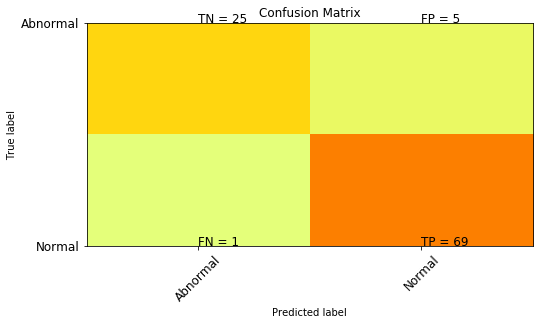

In [15]:
y_pred_suitable = y_pred_dict[4]
labels = [0,1]
confusion_matrix = metrics.confusion_matrix(y_test.values,y_pred_suitable,labels)
true_negative, false_positive, false_negative, true_positive = confusion_matrix.ravel()
print("True negative :- ",true_negative)
print("False positive :- ",false_positive)
print("False negative :- ",false_negative)
print("True positive :- ",true_positive)
print("----------------------------------------")
print("True positive rate :- ",true_positive/(true_positive + false_negative))
print("True negative rate :- ",true_negative/(true_negative + false_positive))

plt.clf()
plt.figure(figsize=(8,8))
plt.imshow(confusion_matrix, interpolation='nearest', cmap=plt.cm.Wistia)
classNames = ['Abnormal','Normal']
plt.title('Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
tick_marks = np.arange(len(classNames))
plt.xticks(tick_marks, classNames, rotation = 45,fontsize = 12)
plt.yticks(tick_marks, classNames, fontsize = 12)
s = [['TN','FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        plt.text(j,i, str(s[i][j])+" = "+str(confusion_matrix[i][j]),fontsize=12)
plt.show()

In [16]:
# classification report
print(metrics.classification_report(y_test.values, y_pred_suitable, target_names = classNames))

              precision    recall  f1-score   support

    Abnormal       0.96      0.83      0.89        30
      Normal       0.93      0.99      0.96        70

    accuracy                           0.94       100
   macro avg       0.95      0.91      0.93       100
weighted avg       0.94      0.94      0.94       100



#### 1c(iii). Since the computation time depends on the size of the training set, one may only  use  a  subset  of  the  training  set.   Plot  the best test error rate which is  obtained  by  some  value  of k,  against  the  size  of  training  set,  when  the size  of  training  set  is N∈ {10,20,30, . . . ,210}.3 Note:  for  each N,  select your  training  set  by  choosing  the  first N/3 rows  of  Class  0  and  the  first N−N/3 rows of Class 1 in the training set you created in 1(b)iii.  Also, for each N, select the optimal k from a set starting from k= 1, increasing by 5.For example, if N= 200, the optimal k is selected from{1,6,11, . . . ,196}.This plot is called a Learning Curve

Text(0.5, 1.0, 'Learning Curve')

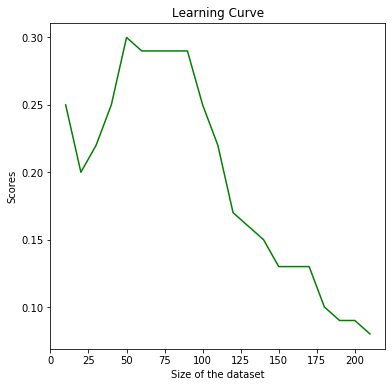

In [17]:
N_list = list(range(10,220,10))
test_scores_compute = {}
for N in N_list:
    sub_train = pd.concat([training[training.result == 0][0:math.floor(N/3)],training[training.result == 1][0:(N-math.floor(N/3))]])
    k_range = list(range(1,N,5))
    X_ = sub_train.iloc[:,0:6]
    y_ = sub_train.iloc[:,6]
    test_scores_k = {}
    
    for k in k_range:
        model = KNeighborsClassifier(n_neighbors = k, p = 2, metric = 'euclidean')
        model.fit(X_,y_)
        test_score = model.score(X_test,y_test)
        #print(k, " ",test_score," ",N)
        test_scores_k[k] = 1 - test_score
    test_scores_compute[N] = test_scores_k

error_rate = []
for key,val in test_scores_compute.items():
    min_score = min(test_scores_compute[key].values())
    error_rate.append(min_score)
plt.figure(figsize=(6,6))
plt.plot(N_list,error_rate, color = 'green',label='Learning curve')
plt.xlabel('Size of the dataset')
plt.ylabel('Scores')
plt.title('Learning Curve')    

### 1d. Replace the Euclidean metric with the following metrics and test them.  Summarize the test errors (i.e., when k = k∗) in a table.  Use all of your training data and select the best k when {1,6,11, . . . ,196}

In [18]:
X_train = training.iloc[:,0:6]
y_train = training.iloc[:,6]
X_test = testing.iloc[:,0:6]
y_test = testing.iloc[:,6]

#### 1d (i)A Minkowski Distance which becomes Manhattan Distance with p= 1

[1, 6, 11, 16, 21, 26, 31, 36, 41, 46, 51, 56, 61, 66, 71, 76, 81, 86, 91, 96, 101, 106, 111, 116, 121, 126, 131, 136, 141, 146, 151, 156, 161, 166, 171, 176, 181, 186, 191, 196]


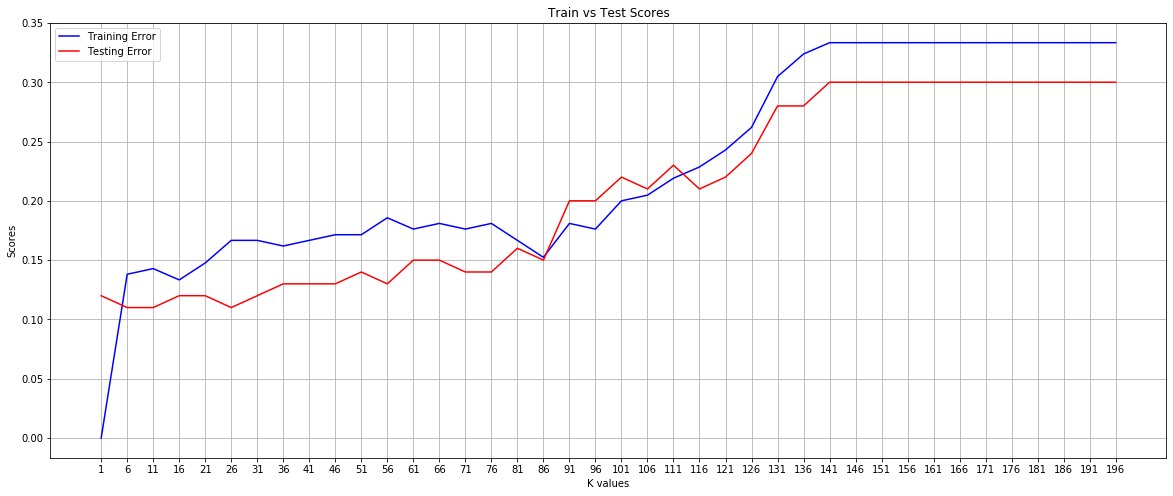

In [19]:
k_list = list(range(1,201,5))
print(k_list)

# accuracy scores
manhattan_train_scores = []
manhattan_test_scores = []
y_pred_dict = {}
for k in k_list:
    #print(k," done")
    model = KNeighborsClassifier(n_neighbors = k, p = 1, metric = 'manhattan')
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    y_pred_dict[k] = y_pred
    train_score = model.score(X_train,y_train)
    test_score = model.score(X_test,y_test)
    manhattan_train_scores.append(1-train_score)
    manhattan_test_scores.append(1-test_score)
    
# Plotting train vs test errors for every K
plt.figure(figsize = (20,8))
plt.plot(k_list,manhattan_train_scores, color = 'blue',label = 'Training Error')
plt.plot(k_list,manhattan_test_scores, color = 'red',label = 'Testing Error')
plt.xticks(np.arange(1, 201, step = 5))
plt.xlabel('K values')
plt.ylabel('Scores')
plt.title('Train vs Test Scores')    
plt.legend()
plt.grid()

#### Best k is k = 6 with the least test error rate of 10% and training error rate of 14%

In [20]:
k_best_values.append(6)
all_test_errors.append(manhattan_test_scores[k_list.index(6)])

#### 1d(i)B  Minkowski distance with log10(p) ∈  {0.1,0.2,0.3, . . . ,1}.  In this case, use the k∗you found for the Manhattan distance in 1(d)iA.  What is the best log10(p)?

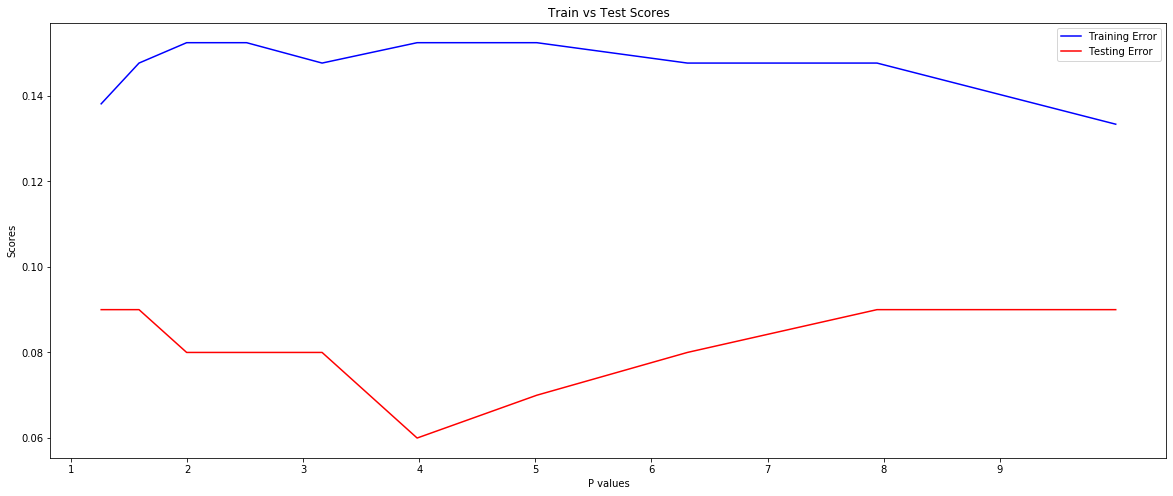

In [21]:
def frange(start, end=None, inc=None):
    "A range function, that does accept float increments..."
    if end == None:
        end = start + 0.0
        start = 0.0
    if inc == None:
        inc = 1.0
    L = []
    while 1:
        next = start + len(L) * inc
        if inc > 0 and next >= end:
            break
        elif inc < 0 and next <= end:
            break
        L.append(next)
    return L


log_p = [(lambda x: math.pow(10,x))(x) for x in frange(0.1,1.1,0.1)]
# accuracy scores
log_train_scores = []
log_test_scores = []
y_pred_dict = {}
for p_ in log_p:
    model = KNeighborsClassifier(n_neighbors = 6, p = p_)
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    y_pred_dict[k] = y_pred
    train_score = model.score(X_train,y_train)
    test_score = model.score(X_test,y_test)
    log_train_scores.append(1-train_score)
    log_test_scores.append(1-test_score)
    
# Plotting train vs test errors for every K
plt.figure(figsize = (20,8))
plt.plot(log_p,log_train_scores, color = 'blue',label = 'Training Error')
plt.plot(log_p,log_test_scores, color = 'red',label = 'Testing Error')
plt.xticks(np.arange(1, 10, step = 1))
plt.xlabel('P values')
plt.ylabel('Scores')
plt.title('Train vs Test Scores')    
plt.legend()
#plt.grid()

####  Best log10(p) is 0.4 where test error rate is 6%

In [22]:
p_values = pd.Series(log_p)
l_test_scores = pd.Series(log_test_scores) 
log_df = pd.concat([p_values,l_test_scores],axis = 1)
log_df.columns = ["P Values","Test Error rates"]
log_df

,P Values,Test Error rates
0,1.258925,0.09
1,1.584893,0.09
2,1.995262,0.08
3,2.511886,0.08
4,3.162278,0.08
5,3.981072,0.06
6,5.011872,0.07
7,6.309573,0.08
8,7.943282,0.09
9,10.000000,0.09


#### 1d(i)C  Minkowski distance which becomes Chebyshev Distance with p→∞

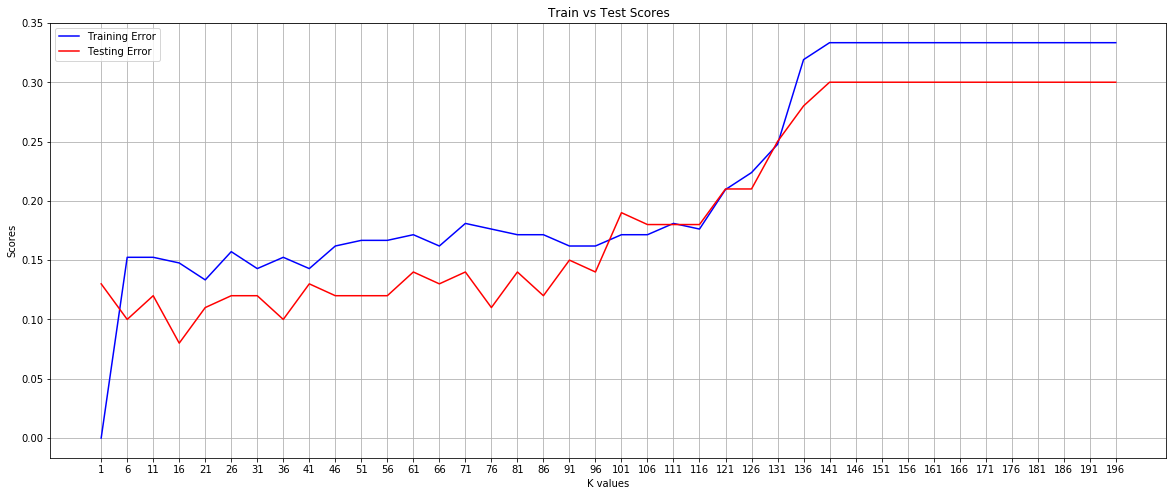

In [23]:
k_list = list(range(1,201,5))


# accuracy scores
chebyshev_train_scores = []
chebyshev_test_scores = []
y_pred_dict = {}
for k in k_list:
    #print(k," done")
    model = KNeighborsClassifier(n_neighbors = k, metric = 'chebyshev')
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    y_pred_dict[k] = y_pred
    train_score = model.score(X_train,y_train)
    test_score = model.score(X_test,y_test)
    chebyshev_train_scores.append(1-train_score)
    chebyshev_test_scores.append(1-test_score)
    
# Plotting train vs test errors for every K
plt.figure(figsize = (20,8))
plt.plot(k_list,chebyshev_train_scores, color = 'blue',label = 'Training Error')
plt.plot(k_list,chebyshev_test_scores, color = 'red',label = 'Testing Error')
plt.xticks(np.arange(1, 201, step = 5))
plt.xlabel('K values')
plt.ylabel('Scores')
plt.title('Train vs Test Scores')    
plt.legend()
plt.grid()

#### Best k is k = 16 with the least test error rate of 7% and training error rate of 15%

In [24]:
k_best_values.append(16)
all_test_errors.append(chebyshev_test_scores[k_list.index(16)])

#### id(ii) Mahalanobis Distance

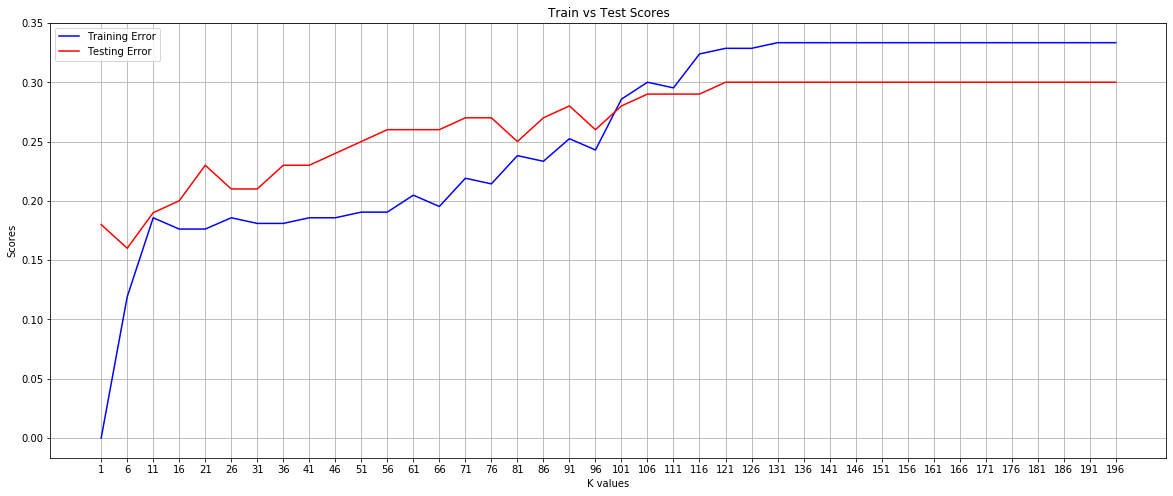

In [25]:
k_list = list(range(1,201,5))

# accuracy scores
mahalanobis_train_scores = []
mahalanobis_test_scores = []

for k in k_list:
    model = KNeighborsClassifier(n_neighbors = k, metric = "mahalanobis", algorithm = "brute", metric_params={'V':np.cov(X_train)})
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    y_pred_dict[k] = y_pred
    train_score = model.score(X_train,y_train)
    test_score = model.score(X_test,y_test)
    mahalanobis_train_scores.append(1-train_score)
    mahalanobis_test_scores.append(1-test_score)
    
# Plotting train vs test errors for every K
plt.figure(figsize = (20,8))
plt.plot(k_list,mahalanobis_train_scores, color = 'blue',label = 'Training Error')
plt.plot(k_list,mahalanobis_test_scores, color = 'red',label = 'Testing Error')
plt.xticks(np.arange(1, 201, step = 5))
plt.xlabel('K values')
plt.ylabel('Scores')
plt.title('Train vs Test Scores')    
plt.legend()
plt.grid()    

#### Best k is k = 6 with the least test error rate of 16% and training error rate of 11%

In [26]:
k_best_values.append(6)
all_test_errors.append(mahalanobis_test_scores[k_list.index(6)])

### 1e. The majority polling decision can be replaced by weighted decision, in which theweight of each point in voting isinversely proportionalto its distance from thequery/test data point.  In this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.  Use weighted voting with  Euclidean,  Manhattan,  and  Chebyshev  distances  and  report  the  best  testerrors whenk∈{1,6,11,16, . . . ,196}

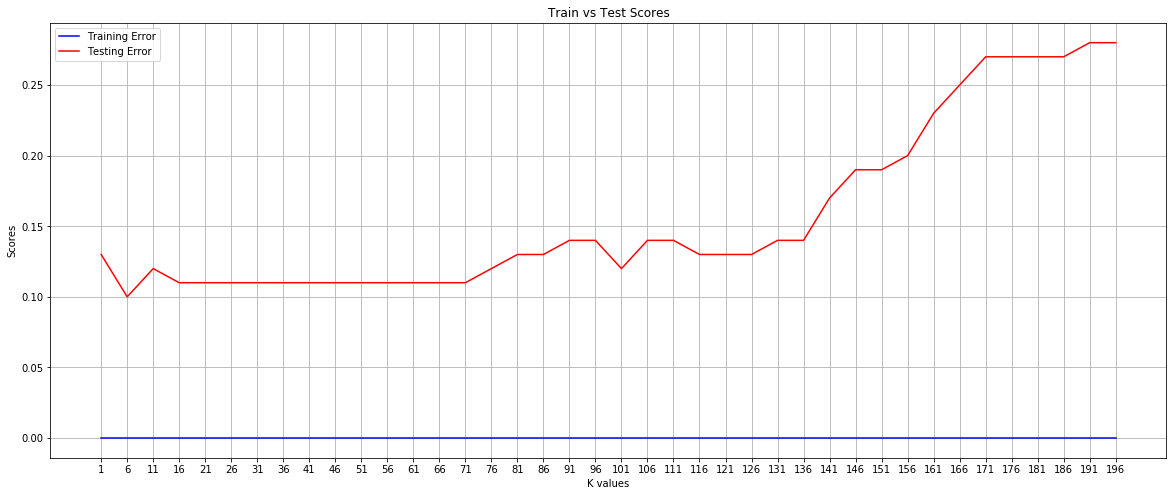

In [27]:
k_list = list(range(1,201,5))

# accuracy scores
weighted_train_scores = []
weighted_test_scores = []
metrics = ["euclidean","manhattan","chebyshev"]

y_pred_dict = {}
for k in k_list:
    #print(k," done")
    model = KNeighborsClassifier(n_neighbors = k, weights = 'distance')
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    y_pred_dict[k] = y_pred
    train_score = model.score(X_train,y_train)
    test_score = model.score(X_test,y_test)
    weighted_train_scores.append(1-train_score)
    weighted_test_scores.append(1-test_score)
    
# Plotting train vs test errors for every K
plt.figure(figsize = (20,8))
plt.plot(k_list,weighted_train_scores, color = 'blue',label = 'Training Error')
plt.plot(k_list,weighted_test_scores, color = 'red',label = 'Testing Error')
plt.xticks(np.arange(1, 201, step = 5))
plt.xlabel('K values')
plt.ylabel('Scores')
plt.title('Train vs Test Scores')    
plt.legend()
plt.grid()

#### The best k is k = 6 with test error rate of 10%

In [28]:
k_best_values.append(6)
all_test_errors.append(weighted_test_scores[k_list.index(6)])

### 1f. What is the lowest training error rate you achieved in this homework?

#### The lowest training error rate achieved is 0%

In [29]:
metric_list = pd.Series(["euclidean","manhattan","chebyshev","mahalanobis","weighted_voting"])
k_values = pd.Series(k_best_values)
all_errors = pd.Series(all_test_errors) 
df = pd.concat([metric_list,k_values,all_errors],axis = 1)
df.columns = ["Metric","K Values","Test Error rates"]
df

,Metric,K Values,Test Error rates
0,euclidean,4,0.06
1,manhattan,6,0.11
2,chebyshev,16,0.08
3,mahalanobis,6,0.16
4,weighted_voting,6,0.10
